# Inleiding

Dit Jupyter-notebook is ontwikkeld met het doel om inzicht te krijgen in de kolommen die het meest relevant zijn voor de analyses en voorspellende modellen die bij ProRail worden gebruikt. ProRail beheert het Nederlandse spoorwegnetwerk, en bij het analyseren van storingen, onderhoudsgegevens, en contractinformatie zijn nauwkeurige, consistente gegevens essentieel. De selectie van kolommen is gedaan op basis van een analyse van datakwaliteit, volledigheid en relevantie voor de voorspellingen.

De kolommen die uiteindelijk zijn geselecteerd bevatten minder ontbrekende waarden (NaN) en betere consistentie dan de alternatieven, wat belangrijk is voor het trainen van voorspellende modellen. Deze kolommen vertegenwoordigen cruciale gegevenscategorieën zoals locatie, tijd, contractinformatie, oorzaak en statusprognose, die samen een goed beeld geven van storingen en onderhoudsactiviteiten. Dit document biedt een overzicht van de methoden die zijn gebruikt om inconsistente gegevens te identificeren en te selecteren welke kolommen het meest geschikt zijn.

In [1]:
# Bibliotheken
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Data laden
data = pd.read_csv("source/sap_storing_data_hu_project.csv", index_col=0, low_memory=False)

data.head()

,#stm_sap_meldnr,stm_mon_nr,stm_vl_post,stm_sap_meld_ddt,stm_sap_mon_meld_ddt,stm_sap_meldtekst_lang,stm_mon_begin_ddt,stm_sap_meldtekst,stm_mon_toelichting_trdl,stm_oh_pg_mld,...,stm_rapportage_maand,stm_rapportage_jaar,stm_x_bron_publ_dt,stm_x_bron_bestandsnaam,stm_x_bron_arch_dt,stm_x_actueel_ind,stm_x_run_id,stm_x_bk,stm_x_start_sessie_dt,stm_x_vervallen_ind
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5,2014,07/05/2014 05:30:12,\\PUHAPS0149\Informatica_Prod\Inbox\Informatic...,31/12/9999 00:00:00,1,34415,3617016,07/05/2014 05:44:24,0
1,50053211,0.0,NaN,02/01/2006 09:00:00,02/01/2006 09:00:00,Logboeknr Geeltje : 49 Tijd: 0900 VL-Po...,NaN,Logboeknr Geeltje : 49 Tijd: 0900,NaN,NaN,...,1,2006,02/01/2006 09:00:00,\\PUHAPS0149\Informatica_Prod\Inbox\Informatic...,31/12/9999 00:00:00,1,1518,12704590,13/06/2013 13:37:52,0
2,50053213,48.0,GN,02/01/2006 12:35:00,02/01/2006 12:35:00,Logboeknr RBV : 48 Tijd: 1235 VL-Post: ...,02/01/2006 12:35:00,Logboeknr RBV : 48 Tijd: 1235 VL-P,NaN,NaN,...,1,2006,02/01/2006 12:35:00,\\PUHAPS0149\Informatica_Prod\Inbox\Informatic...,31/12/9999 00:00:00,1,1518,12704591,13/06/2013 13:37:52,0
3,50053214,72.0,ZL,02/01/2006 16:40:00,02/01/2006 16:40:00,Logboeknr RBV : 72 Tijd: 1640 VL-Post: ...,02/01/2006 16:40:00,Logboeknr RBV : 72 Tijd: 1640 VL-P,NaN,NaN,...,1,2006,02/01/2006 16:40:00,\\PUHAPS0149\Informatica_Prod\Inbox\Informatic...,31/12/9999 00:00:00,1,1518,12704592,13/06/2013 13:37:52,0
4,50053215,96.0,ZL,02/01/2006 22:30:00,02/01/2006 22:30:00,Logboeknr RBV : 96 Tijd: 2230 VL-Post: ...,02/01/2006 22:30:00,Logboeknr RBV : 96 Tijd: 2230 VL-P,NaN,NaN,...,1,2006,02/01/2006 22:30:00,\\PUHAPS0149\Informatica_Prod\Inbox\Informatic...,31/12/9999 00:00:00,1,1518,12704593,13/06/2013 13:37:52,0


In [5]:
# Opschonen van kolommen namen in de dataset
data.columns = data.columns.str.replace("#", "")

## Analyse van ongeldige Locatiegerelateerde waardes in stm_geo_mld & stm_geo_gst

Aantal nan waardes in 'stm_geo_mld': 11833
Aantal nan waardes in 'stm_geo_gst': 156202


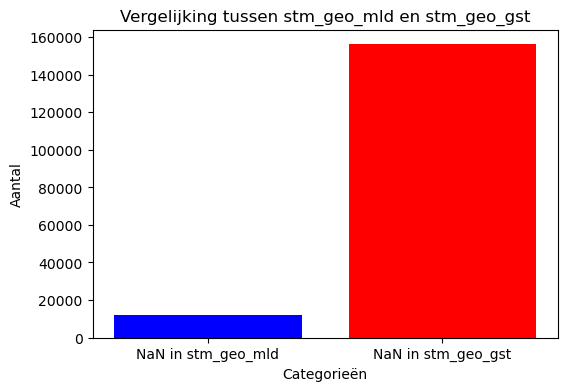

In [6]:
# Maak lijsten voor Locatiegerelateerde kolommen stm_geo_mld & stm_geo_gst
geo_mld = data['stm_geo_mld'].astype(str).str.strip().tolist()
geo_gst = data['stm_geo_gst'].astype(str).str.strip().tolist()

# Initialiseert tellers voor mismatches
mismatches = 0
mld_nan_count = 0
gst_nan_count = 0

# Doorloop de lijsten en vergelijk per index
for i in range(len(geo_mld)):    
    if geo_mld[i] == 'nan':
        mld_nan_count += 1
        
    if geo_gst[i] == 'nan':
        gst_nan_count += 1
        
print(f"Aantal nan waardes in 'stm_geo_mld': {mld_nan_count}")
print(f"Aantal nan waardes in 'stm_geo_gst': {gst_nan_count}")

# Labels en waarden voor de grafiek
labels = ['NaN in stm_geo_mld', 'NaN in stm_geo_gst']
values = [mld_nan_count, gst_nan_count]

# Maak een staafgrafiek
plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=['blue', 'red'])
plt.title('Vergelijking tussen stm_geo_mld en stm_geo_gst')
plt.xlabel('Categorieën')
plt.ylabel('Aantal')

# Plot tonen
plt.show()

### Conclusie

Vanwege de lagere hoeveelheid ontbrekende waarden is stm_geo_mld de betere keuze. De data in stm_geo_mld lijkt vollediger en betrouwbaarder voor nauwkeurige locatieanalyse, terwijl stm_geo_gst een groot aantal ontbrekende waarden die de nauwkeurigheid van analyses kunnen beïnvloeden.

## Analyse van ongeldige Tijdgerelateerde kolommen in stm_sap_melddatum, stm_sap_meldtijd & stm_sap_meld_ddt

In [7]:
# Maak lijsten voor datum- en tijdgegevens
melddatum_list = data['stm_sap_melddatum'].astype(str).str.strip().tolist()
meldtijd_list = data['stm_sap_meldtijd'].astype(str).str.strip().tolist()

# Maak een lijst voor de gecombineerde datum-tijd kolom en splits deze in datum- en tijdgedeeltes
meld_ddt_split = data['stm_sap_meld_ddt'].astype(str).str.strip().str.split(' ', expand=True)
meld_ddt_date_list = meld_ddt_split[0].tolist()  # Datumgedeelte
meld_ddt_time_list = meld_ddt_split[1].tolist()  # Tijdgedeelte

# Initialiseert tellers voor mismatches
date_mismatches = 0
time_mismatches = 0

# Doorloop de lijsten en vergelijk per index
for i in range(len(melddatum_list)):
    # Vergelijk datum
    if melddatum_list[i] != meld_ddt_date_list[i]:
        date_mismatches += 1
    
    # Vergelijk tijd
    if meldtijd_list[i] != meld_ddt_time_list[i]:
        time_mismatches += 1

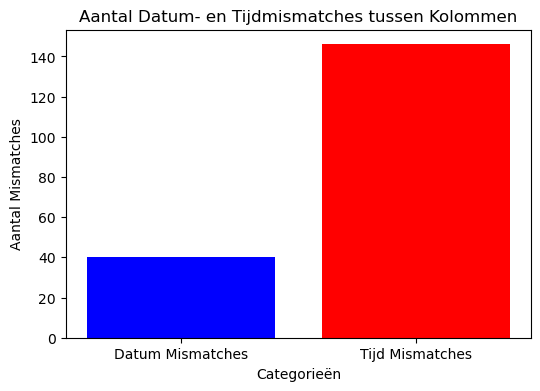

In [8]:
# Labels en waarden
labels = ['Datum Mismatches', 'Tijd Mismatches']
values = [date_mismatches, time_mismatches]

# Maak de staafgrafiek
plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=['blue', 'red'])
plt.title('Aantal Datum- en Tijdmismatches tussen Kolommen')
plt.xlabel('Categorieën')
plt.ylabel('Aantal Mismatches')

# Plot tonen
plt.show()

### Conclusie

De tijden in stm_sap_meld_ddt zijn nauwkeuriger, omdat stm_sap_melddatum en stm_sap_meldtijd een hoger aantal NaN en lege waarden bevatten. Bovendien komen er bij stm_sap_meldtijd herhaaldelijk dubbele punten (::) voor in plaats van geldige tijdswaarden, wat aangeeft dat deze kolommen minder betrouwbaar zijn voor consistente tijdsgegevens.

## Analyse van ongeldige Datum en Tijden waardes in stm_aanngeb_dd, stm_aanngeb_tijd & stm_aanngeb_ddt

In [9]:
# Maak lijsten voor datum- en tijdgegevens
aanngeb_dd_list = data['stm_aanngeb_dd'].astype(str).str.strip().tolist()
aanngeb_tijd_list = data['stm_aanngeb_tijd'].astype(str).str.strip().tolist()

# Maak een lijst voor de gecombineerde datum-tijd kolom en splits deze in datum- en tijdgedeeltes
aanngeb_ddt_split = data['stm_aanngeb_ddt'].astype(str).str.strip().str.split(' ', expand=True)
aanngeb_date_list = aanngeb_ddt_split[0].tolist()  # Datumgedeelte
aanngeb_time_list = aanngeb_ddt_split[1].tolist()  # Tijdgedeelte

# Initialiseert tellers voor mismatches
aanngeb_dd_mismatches = 0
aanngeb_tijd_mismatches = 0

# Doorloop de lijsten en vergelijk per index
for i in range(len(aanngeb_dd_list)):
    # Vergelijk datum
    if aanngeb_dd_list[i] != aanngeb_date_list[i]:
        aanngeb_dd_mismatches += 1
    
    # Vergelijk tijd
    if aanngeb_tijd_list[i] != aanngeb_time_list[i]:
        aanngeb_tijd_mismatches += 1

# Resultaat weergeven
print(f"Aantal datum mismatches: {aanngeb_dd_mismatches}")
print(f"Aantal tijd mismatches: {aanngeb_tijd_mismatches}")

Aantal datum mismatches: 61
Aantal tijd mismatches: 33598


## Analyse van Tijd- en Datumverschillen

### 1. Ontbrekende Tijd en Datum in stm_aanngeb_ddt wanneer stm_aanngeb_tijd ontbreekt:

Wanneer er geen tijd wordt ingevuld in stm_aanngeb_tijd, is zowel de tijd als de datum vaak ook niet aanwezig in stm_aanngeb_ddt.
Voorbeelden van dit patroon:
Datum mismatch op index 2928: 18/08/2006 vs NaN
Tijd mismatch op index 2928: :: vs None
Andere indices: 3436, 3491, 4892.

### 2. 00:00:00 in stm_aanngeb_tijd komt overeen met een None-waarde in stm_aanngeb_ddt:

Wanneer stm_aanngeb_tijd op 00:00:00 staat, is de overeenkomstige tijdswaarde in stm_aanngeb_ddt vaak leeg (None).
Voorbeelden van dit patroon:
Tijd mismatch op index 104707: 00:00:00 vs None
Andere indices: 104711, 104713, 104716, 104718.

### 3. Ontbrekende Datum & Tijd in zowel stm_aanngeb_dd als stm_aanngeb_tijd:

Op specifieke indices zijn zowel stm_aanngeb_dd als stm_aanngeb_tijd leeg, wat duidt op een volledige afwezigheid van tijd- en datumgegevens.
Betrokken indices:
[606548, 608623, 609721, 629002, 629122, 634822, 635151, 635437, 637861, 648606, 654069, 654087, 654890, 657690, 704003, 704004, 709929, 715806, 715807, 717297, 717335, 717336, 720579, 722500, 722501, 725984, 727528, 727529, 727530, 727531, 728881, 739802]

### 4. Ontbrekende Tijd aan beide zijden (zowel stm_aanngeb_tijd als stm_aanngeb_ddt):

In alleen maar 3 gevallen ontbreekt de tijdsinformatie volledig in beide kolommen.
Betrokken indices:
896775, 896793, 898179

### 5. Tijd aanwezig in stm_aanngeb_tijd maar ontbrekend in stm_aanngeb_ddt:

Op bepaalde indices is de tijd ingevuld in stm_aanngeb_tijd, maar ontbreekt deze in stm_aanngeb_ddt.
Betrokken indices:
Tijd mismatch op index 897183: 14:39:00 vs None
Tijd mismatch op index 897186: 15:06:00 vs None

### 6. De meeste tijd mismatches zijn van het patroon 00:00:00 vs None:

Bij het merendeel van de tijdsmismatches zien we een patroon waarin stm_aanngeb_tijd 00:00:00 bevat, terwijl stm_aanngeb_ddt geen waarde heeft (None).

### Conclusie
Op basis van deze observaties lijkt het erop dat de gegevens in stm_aanngeb_dd en stm_aanngeb_tijd nauwkeuriger en consistenter zijn dan de gecombineerde stm_aanngeb_ddt-kolom. Daarom is het logisch om stm_aanngeb_ddt te verwijderen, zodat we ons kunnen concentreren op de afzonderlijke stm_aanngeb_dd en stm_aanngeb_tijd kolommen, die een betere representatie lijken te geven van de datum- en tijdsinformatie.

## Analyse van ongeldige Datum en Tijden waardes in stm_fh_tijd & stm_fh_dd

### 1. Patroon van ontbrekende of ongeldige waarden in stm_fh_tijd en stm_fh_dd:

Wanneer stm_fh_tijd de waarde 00:00:00 bevat, is stm_aanntpl_dd vaak NaN, en blijkt stm_fh_dd vaak ongeldige datums te bevatten.
Om dit patroon van onlogische en inconsistente waarden op te schonen, worden ongeldige waarden in stm_fh_tijd, stm_fh_dd, en stm_fh_ddt vervangen door NaN.

In [10]:
# Ongeldige waarden in 'stm_fh_tijd', 'stm_fh_dd', en 'stm_fh_ddt' vervangen door NaN
data['stm_fh_tijd'].replace('00:00:00', np.nan, inplace=True)
data['stm_fh_dd'].replace(['00000000', '0.0', '0'], np.nan, inplace=True)

### 2. Ongelijkheden tussen stm_fh_dd, stm_fh_tijd en stm_fh_ddt:

In [11]:
# Verdeel 'stm_fh_ddt' in datum- en tijdgedeelte voor verdere vergelijking
fh_ddt_split = data['stm_fh_ddt'].astype(str).str.split(' ', expand=True)
fh_ddt_date_list = fh_ddt_split[0].replace('nan', np.nan).tolist()  # Datumgedeelte
fh_ddt_time_list = fh_ddt_split[1].replace('nan', np.nan).tolist()  # Tijdgedeelte

# Maak lijsten voor datum- en tijdgegevens
fh_dd_list = data['stm_fh_dd'].tolist()
fh_tijd_list = data['stm_fh_tijd'].tolist()

# Tellers voor mismatches en indices van rijen met verschillen
fh_dd_mismatches = 0
fh_tijd_mismatches = 0

# Doorloop de lijsten en vergelijk per index
for i in range(len(fh_dd_list)):
    # Controleer datum mismatch
    if fh_dd_list[i] != fh_ddt_date_list[i] and not (pd.isna(fh_dd_list[i]) and pd.isna(fh_ddt_date_list[i])):
        fh_dd_mismatches += 1
    
    # Controleer tijd mismatch
    if fh_tijd_list[i] != fh_ddt_time_list[i] and not (pd.isna(fh_tijd_list[i]) and pd.isna(fh_ddt_time_list[i])):
        fh_tijd_mismatches += 1

# Resultaat weergeven
print(f"Aantal datum mismatches tussen 'stm_fh_dd' en 'stm_fh_ddt' (datumgedeelte): {fh_dd_mismatches}")
print(f"Aantal tijd mismatches tussen 'stm_fh_tijd' en 'stm_fh_ddt' (tijdgedeelte): {fh_tijd_mismatches}")

Aantal datum mismatches tussen 'stm_fh_dd' en 'stm_fh_ddt' (datumgedeelte): 31
Aantal tijd mismatches tussen 'stm_fh_tijd' en 'stm_fh_ddt' (tijdgedeelte): 169


### 3. Resultaten van de Vergelijking:

Datum mismatches: Er zijn 31 gevallen waarin stm_fh_dd afwijkt van het datumgedeelte van stm_fh_ddt. Dit zijn vaak gevallen waarin stm_fh_dd een datum bevat terwijl stm_fh_ddt een ontbrekende waarde (NaN) heeft.
Tijd mismatches: Er zijn 169 gevallen van tijd mismatches tussen stm_fh_tijd en stm_fh_ddt (tijdgedeelte). Veel van deze verschillen treden op wanneer stm_fh_tijd een ontbrekende waarde heeft (NaN), terwijl stm_fh_ddt de tijd 00:00:00 bevat, wat als een overbodige waarde kan worden beschouwd.

### 4. Conclusie en Verwijdering van stm_fh_ddt:

Gezien de inconsistenties en het aantal onlogische waarden in stm_fh_ddt, wordt besloten om de kolom stm_fh_ddt te verwijderen. De informatie in stm_fh_dd en stm_fh_tijd biedt meer consistente en bruikbare gegevens.

## Analyse van ongeldige Contract en Equipmentinformatie

Aantal nan waardes in 'stm_contractgeb_mld' 237509
Aantal nan waardes in 'stm_contractgeb_gst' 223


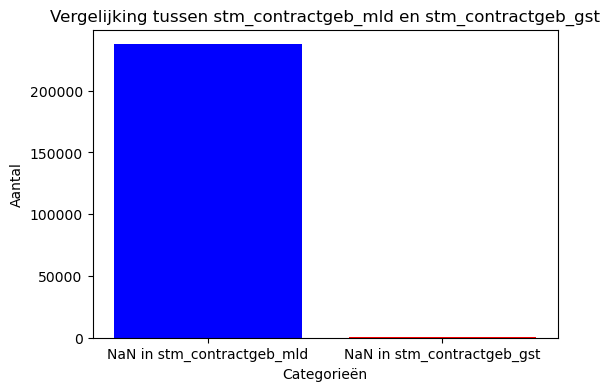

In [12]:
# Maak lijsten voor Contract gerelateerde kolommen stm_contractgeb_mld & stm_contractgeb_gst
contractgeb_mld = data["stm_contractgeb_mld"].tolist()
contractgeb_gst = data["stm_contractgeb_gst"].tolist()

# Initialiseert tellers voor NaN waarden
contractgeb_mld_nan_count = 0
contractgeb_gst_nan_count = 0

# Doorloop de lijsten en tel NaN waarden
for i in range(len(contractgeb_mld)):
    if pd.isna(contractgeb_mld[i]):
        contractgeb_mld_nan_count += 1
    if pd.isna(contractgeb_gst[i]):
        contractgeb_gst_nan_count += 1
        
print(f"Aantal nan waardes in 'stm_contractgeb_mld' {contractgeb_mld_nan_count}")
print(f"Aantal nan waardes in 'stm_contractgeb_gst' {contractgeb_gst_nan_count}")

# Labels en waarden voor de grafiek
labels = ['NaN in stm_contractgeb_mld', 'NaN in stm_contractgeb_gst']
values = [contractgeb_mld_nan_count, contractgeb_gst_nan_count]

# Maak een staafgrafiek
plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=['blue', 'red'])
plt.title('Vergelijking tussen stm_contractgeb_mld en stm_contractgeb_gst')
plt.xlabel('Categorieën')
plt.ylabel('Aantal')

# Plot tonen
plt.show()

### Conclusie

Het aantal NaN (Not a Number) waarden in de 'stm_contractgeb_mld' kolom is zeer hoog, met 237.509 NaN waarden. In contrast, het aantal NaN waarden in de 'stm_contractgeb_gst' kolom is relatief laag, met slechts 223 NaN waarden. De gegevens in 'stm_contractgeb_mld' lijken veel minder consistent en volledig te zijn dan de gegevens in 'stm_contractgeb_gst'.

# Analyse van ongeldige Techniekveld melding data

Aantal nan waardes in 'stm_techn_mld' 234127
Aantal nan waardes in 'stm_techn_gst' 223


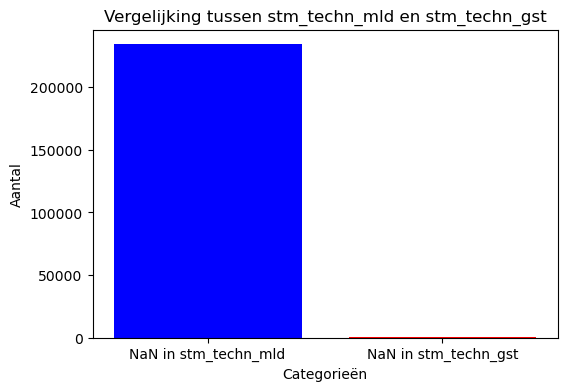

In [13]:
# Maak lijsten voor Technische kolommen stm_techn_mld & stm_techn_gst
techn_mld = data["stm_techn_mld"].tolist()
techn_gst = data["stm_techn_gst"].tolist()

# Initialiseert tellers voor NaN waarden
techn_mld_nan_count = 0
techn_gst_nan_count = 0

# Doorloop de lijsten en tel NaN waarden
for i in range(len(techn_mld)):
    if pd.isna(techn_mld[i]):
        techn_mld_nan_count += 1
    if pd.isna(techn_gst[i]):
        techn_gst_nan_count += 1
        
print(f"Aantal nan waardes in 'stm_techn_mld' {techn_mld_nan_count}")
print(f"Aantal nan waardes in 'stm_techn_gst' {techn_gst_nan_count}")

# Labels en waarden voor de grafiek
labels = ['NaN in stm_techn_mld', 'NaN in stm_techn_gst']
values = [techn_mld_nan_count, techn_gst_nan_count]

# Maak een staafgrafiek
plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=['blue', 'red'])
plt.title('Vergelijking tussen stm_techn_mld en stm_techn_gst')
plt.xlabel('Categorieën')
plt.ylabel('Aantal')

# Plot tonen
plt.show()

### Conclusie

Het aantal NaN (Not a Number) waarden in de 'stm_techn_mld' kolom is extreem hoog, met 234.127 rijen (circa 26% van het totaal) waar de technische informatie ontbreekt.
In contrast hiermee is het aantal NaN waarden in de 'stm_techn_gst' kolom relatief laag, met slechts 223 rijen (minder dan 0.03%) waar de informatie ontbreekt.

### Belangrijkste Selectiecriteria

Volledigheid van gegevens: De kolommen zijn geselecteerd op basis van het aantal ontbrekende waarden. Een lagere aanwezigheid van NaN-waarden betekent dat de gegevens consistenter en betrouwbaarder zijn, wat vooral belangrijk is bij het trainen van voorspellende modellen.

Relevantie voor het model: De geselecteerde kolommen bevatten informatie die cruciaal is voor analyses van tijd, locatie en contractinformatie, en worden meestal gebruikt in voorspellende analyses bij ProRail. Door de informatie in specifieke kolommen zoals stm_sap_meld_ddt en stm_geo_mld kunnen bijvoorbeeld nauwkeurige voorspellingen worden gemaakt over storingspatronen en de benodigde resources.

Geschiktheid voor voorspellende modellen: Waar mogelijk zijn kolommen geselecteerd die een eenduidige en consistente structuur bieden, wat van cruciaal belang is bij voorspellende modellering. Door te kiezen voor kolommen met consistente waarden, wordt de kans op modelafwijkingen als gevolg van foutieve gegevens geminimaliseerd.

### Toelichting van de Geselecteerde Kolommen

#### Locatiegerelateerde Variabelen:

##### stm_geo_mld: 
Deze kolom bevat locatiegegevens met relatief weinig ontbrekende waarden in vergelijking met alternatieven zoals stm_geo_gst. Dit maakt stm_geo_mld betrouwbaarder voor locatie-analyses.
Tijdgerelateerde Variabelen:

##### stm_sap_meld_ddt: 
Deze kolom biedt een volledige datum-tijd weergave en bleek minder inconsistenties en ontbrekende waarden te bevatten dan de afzonderlijke datum (stm_sap_melddatum) en tijd (stm_sap_meldtijd) kolommen.
##### stm_aanngeb_dd, stm_aanntpl_dd, stm_aanntpl_tijd, stm_fh_dd: 
Deze kolommen bieden tijdsgegevens die belangrijk zijn voor het bepalen van de timing van onderhoud en reparaties. Door consistentie in tijdsgegevens kan het model betere schattingen maken.

#### Contract- en Equipmentinformatie:

##### stm_equipm_nr_mld, stm_equipm_soort_mld, stm_contractgeb_gst, stm_techn_gst: 
Voor deze kolommen is gekozen vanwege hun volledigheid en lagere aanwezigheid van ontbrekende waarden, waardoor een vollediger en betrouwbaarder overzicht van de contracten en technische informatie mogelijk is.

#### Oorzaakinformatie:

##### stm_oorz_groep en stm_oorz_code: 
Deze kolommen bevatten gedetailleerde informatie over de oorzaak van storingen, wat essentieel is voor het identificeren van patronen en mogelijke oorzaken van storingen. Ze bieden consistentie en volledigheid, wat nodig is om accurate analyses en voorspellingen te maken.

#### Prognose- en Statusvariabelen:

##### stm_progfh_in_datum, stm_progfh_in_tijd, stm_prioriteit, stm_progfh_in_duur: 
Deze kolommen helpen bij het voorspellen van de duur en prioriteit van storingen, wat essentieel is voor resourceplanning.

### Conclusie

De gekozen kolommen voldoen aan belangrijke vereisten voor ProRail. De geselecteerde variabelen zijn niet alleen consistent en volledig, maar vertegenwoordigen ook de belangrijkste gegevenscategorieën die nodig zijn voor voorspellende analyses. Door de selectie van deze kolommen kan het model storingen en onderhoudsbehoeften nauwkeuriger voorspellen, wat bijdraagt aan een beter beheerde en efficiëntere spoorweginfrastructuur.